# Practical implementation
## MEasure of central tendency
  1. Mean
  2. Median
  3. Mode

In [72]:
ages=[23,24,32,45,12,43,67,45,32,56,32,120]

In [73]:
import numpy as np
print(np.mean(ages))
print(np.median(ages))

44.25
37.5


In [74]:
import statistics as st
st.mode(ages)

32

In [75]:
import seaborn as sns

<Axes: >

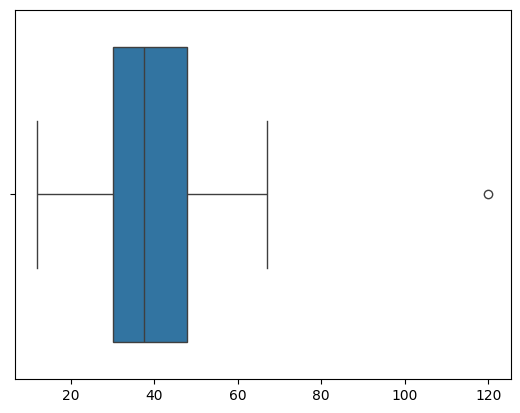

In [76]:
#  It is use to find the outliers
sns.boxplot(x=ages)

# 5 number summery

In [77]:
q1,q3=np.percentile(ages,[25,75])

In [78]:
q3

np.float64(47.75)

In [79]:
#To check outlier [lower fence - higher fence]
IQR=q3-q1
lowerlimit=q1-1.5*IQR
higherlimit=q3+1.5*IQR

In [80]:
lowerlimit


np.float64(3.375)

# Measure of dispersion
1. Varience
2. Standard Deviation

In [83]:
#This use sample formula
st.variance(ages)

795.2954545454545

In [84]:
# This use population formula 
np.var(ages,axis=0)

np.float64(729.0208333333334)

In [89]:
# Manualy calculation using population formula
def varience(data):
    n=len(ages)
    #Mean of the data
    mean=sum(data)/n
    # Varience
    deviation=[(x-mean)**2 for x in data]
    varience=sum(deviation)/n
    return varience

In [91]:
varience(ages)


729.0208333333334

In [97]:
# Manualy calculation using sample formula
def varience(data):
    n=len(ages)
    #Mean of the data
    mean=sum(data)/n
    # Varience
    deviation=[(x-mean)**2 for x in data]
    varience=sum(deviation)/(n-1)
    return varience
varience(ages)

795.2954545454545

In [99]:
# Directly using function
st.pvariance(ages)

729.0208333333334

# Histogram and PDF

In [101]:
import seaborn as sns

<Axes: ylabel='Count'>

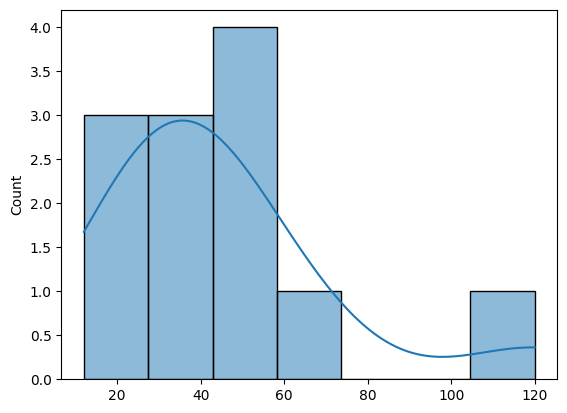

In [110]:
#KDE=kernal density estimationwhich is use to draw that smooth line on histgraph
sns.histplot(ages,kde=True)
# This graph look like a Right skewed graph

In [108]:
df=sns.load_dataset('iris')

In [111]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Count'>

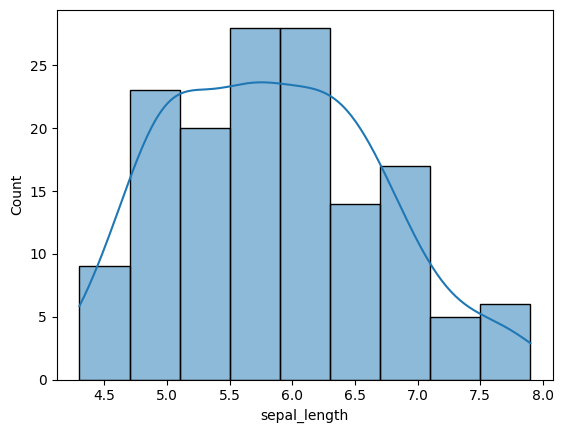

In [114]:
sns.histplot(df['sepal_length'],kde=True)

<Axes: xlabel='sepal_width', ylabel='Count'>

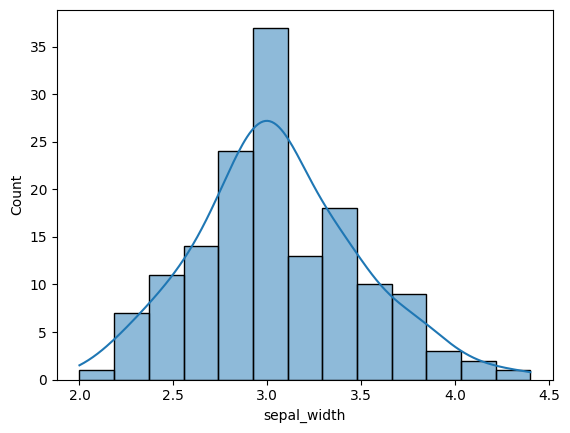

In [117]:
sns.histplot(df['sepal_width'],kde=True)
#

### We can say that this is normal distribution/Caussion distribution 

<Axes: xlabel='petal_length', ylabel='Count'>

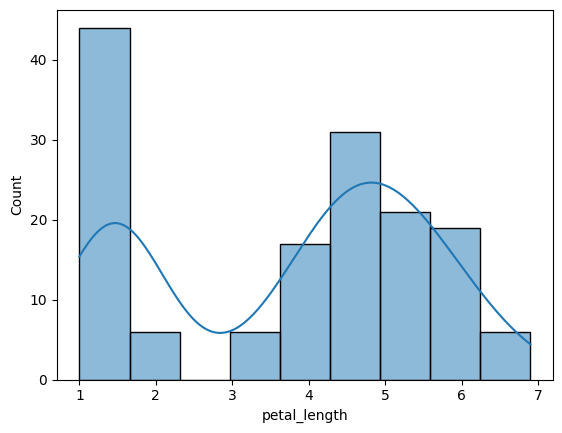

In [119]:
sns.histplot(df['petal_length'],kde=True)

<Axes: xlabel='petal_width', ylabel='Count'>

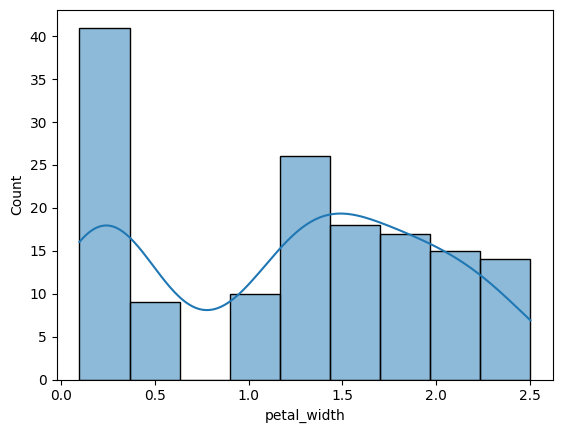

In [121]:
sns.histplot(df['petal_width'],kde=True)

In [124]:
# Create normal distrubution data
# ====== > > >   Normal distribution data means the values are generated from (or closely follow) a Gaussian probability distribution.
s=np.random.normal(loc=0.5,scale=0.2,size=1000)

In [125]:
s

array([ 0.5374044 ,  0.55848444,  0.76632818,  0.54639922,  0.6569038 ,
        0.67415376,  0.508304  ,  0.51556196,  0.13455326,  0.13346922,
        0.40452754,  0.4133678 ,  0.54245602,  0.4656879 ,  0.28999098,
        0.34369592,  0.48839397,  0.35483371,  0.67989933,  0.69904473,
        0.61391441,  0.42247711,  0.64144547,  0.72000211,  0.58801614,
        0.27335227,  0.31836626,  0.5144523 ,  0.5753222 ,  0.27740133,
        0.51714868,  0.03158971,  0.39499533,  0.62153302,  0.75760118,
        0.47246809,  0.5561819 ,  0.80893577,  0.50275312,  0.77783609,
        0.43585939,  0.5829712 ,  0.59507783,  0.50850129,  0.38865211,
        0.30951495,  0.55040932,  0.64523352,  0.59364648,  0.44678952,
        0.39419267,  0.49991983,  0.5949095 ,  0.65554652,  0.40938672,
        0.7572301 ,  0.62645624,  0.61082652,  0.83600899,  0.1739472 ,
        0.5939549 ,  0.70317191,  0.34349952,  0.45195933,  0.67077557,
        0.24585263,  0.40880638,  0.10470055,  0.73258791,  0.10

<Axes: ylabel='Count'>

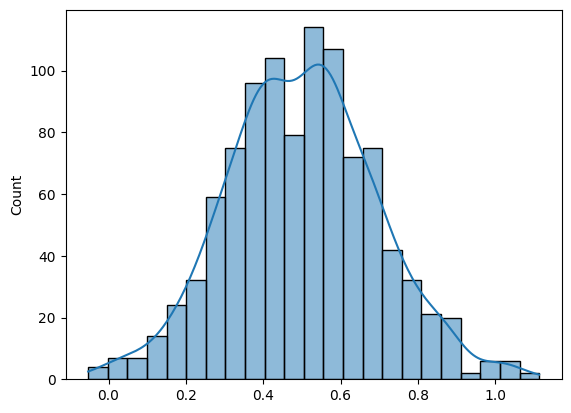

In [127]:
sns.histplot(s,kde=True)

# Other Distribution
# Log normal Distribution,Power Low distribution

In [149]:
# 👉 This generates a log-normal distribution.
mu,sigma=3.,1. #mean and Standard deviation
s=np.random.lognormal(mu,sigma,10)
    

In [150]:
s

array([ 6.33427367, 13.50224538,  4.69211403, 39.59902242, 11.78920172,
       95.7830401 ,  9.63409134,  7.85628083, 17.66012756, 23.13054168])

<Axes: ylabel='Count'>

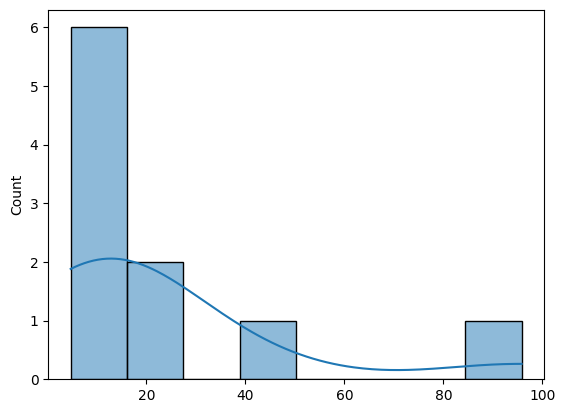

In [151]:
sns.histplot(s,kde=True)

<Axes: ylabel='Count'>

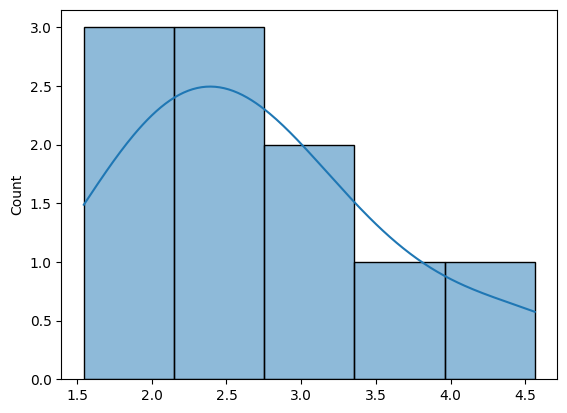

In [152]:
sns.histplot(np.log(s),kde=True)

# How to check distribution is normal distribution or not
Step 1: Visual inspection

1️⃣ Histogram + KDE

2️⃣ Q–Q Plot (most reliable visual)

In [194]:
import matplotlib.pyplot as plt
import scipy.stats as stat
import pylab
def plot_data(sample):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    sns.histplot(sample,kde=True)
    plt.subplot(1,2,2)
    stat.probplot(sample,dist='norm',plot=pylab)
    plt.show()

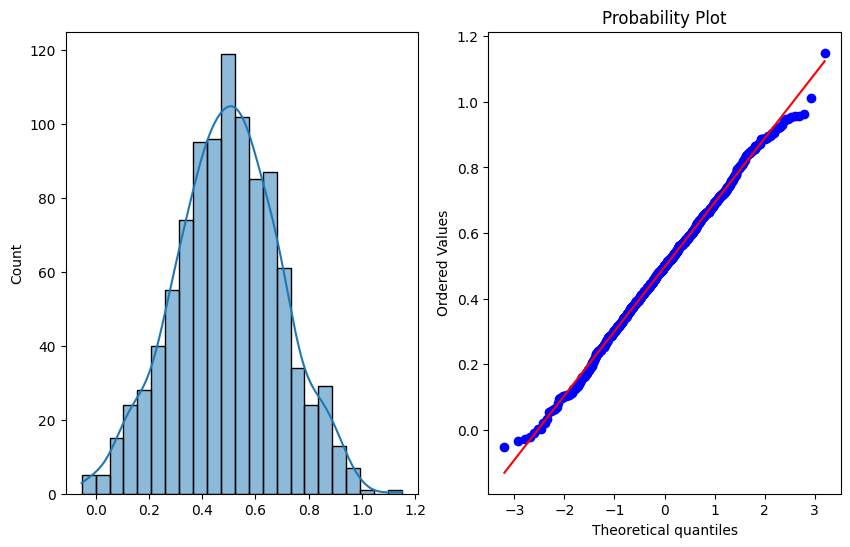

In [196]:
s=np.random.normal(0.5,.2,1000)
plot_data(s)
# Insted of s we can provide df['sepal_width'] this also

# Pearson and sperman Rank Correlation

In [198]:
df=sns.load_dataset('tips')

In [200]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [203]:
import pandas as pd

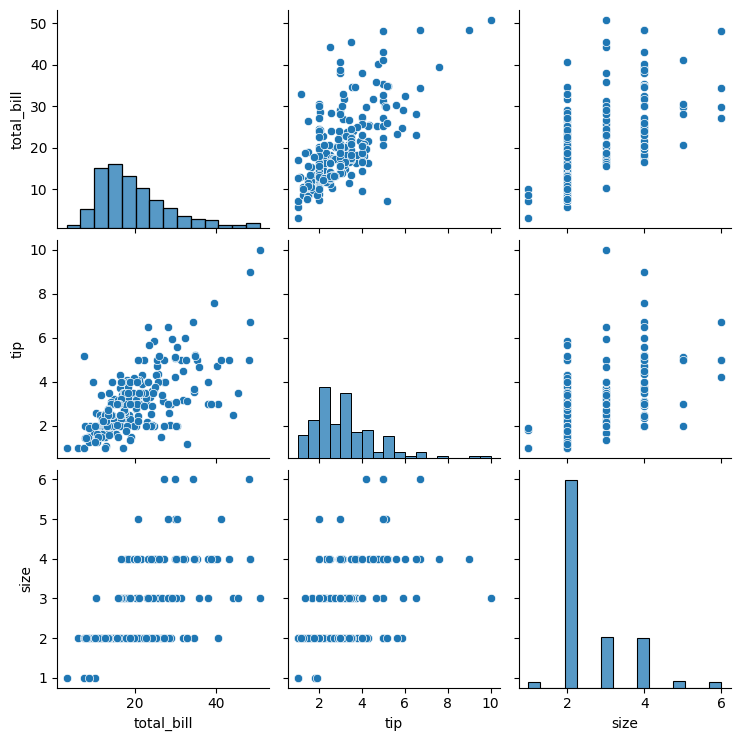

In [205]:
sns.pairplot(df)